# Analyse exploratoire & fusion des jeux de donnees

Objectif : construire un dataset unifie de rendement agricole par culture, enrichi d'un proxy pesticides et d'une validation croisee du rendement.

Sources :
- CropYield Prediction Dataset (crop_yield.csv) : rendement simule a l'echelle de la parcelle, avec region, type de sol, meteo, irrigation, fertilisation et jours de recolte. **C'est notre dataset principal** (table de base, 1M lignes, 6 cultures).
- Agriculture CropYield Dataset (yield_df.csv) : rendement reel par pays / culture / annee (FAO), avec pluviometrie, temperature et pesticides. N'ayant ni pays ni annee dans crop_yield.csv, la seule cle commune est la culture : agrege par culture, ce dataset sert de source d'enrichissement (**proxy pesticides**) et de **reference de validation** du rendement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RAW = "raw_data/"


## 1. Exploration du CropYield Prediction Dataset (`crop_yield.csv`)

Ce jeu de données contient 1 000 000 d'observations à l'échelle de la parcelle : région, type de sol, culture, pluviométrie, température, usage d'engrais/irrigation, météo, jours jusqu'à récolte et rendement. Il n'a **ni pays ni année** — seulement une région générique (East/North/South/West) et une culture. C'est notre dataset principal, la table de base du dataset final.

In [2]:
cy = pd.read_csv(RAW + "crop_yield.csv")
print("Shape:", cy.shape)
display(cy.dtypes)
cy.head()

Shape: (1000000, 10)


Region                        str
Soil_Type                     str
Crop                          str
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition             str
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [3]:
# Valeurs manquantes et doublons
print("Valeurs manquantes par colonne :")
display(cy.isna().sum())
print("\nLignes dupliquées (toutes colonnes) :", cy.duplicated().sum())

Valeurs manquantes par colonne :


Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64


Lignes dupliquées (toutes colonnes) : 0


In [4]:
for col in ["Region", "Soil_Type", "Crop", "Weather_Condition", "Fertilizer_Used", "Irrigation_Used"]:
    print(f"{col}: {sorted(cy[col].unique())}")

cy.describe()

Region: ['East', 'North', 'South', 'West']
Soil_Type: ['Chalky', 'Clay', 'Loam', 'Peaty', 'Sandy', 'Silt']
Crop: ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']
Weather_Condition: ['Cloudy', 'Rainy', 'Sunny']
Fertilizer_Used: [np.False_, np.True_]
Irrigation_Used: [np.False_, np.True_]


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


### Distributions des variables numériques et catégorielles

Un échantillon de 50 000 lignes est utilisé pour les graphiques afin de rester rapide à afficher (le dataset complet compte 1M de lignes) ; les statistiques (`describe`, agrégations) portent elles sur la totalité des données.

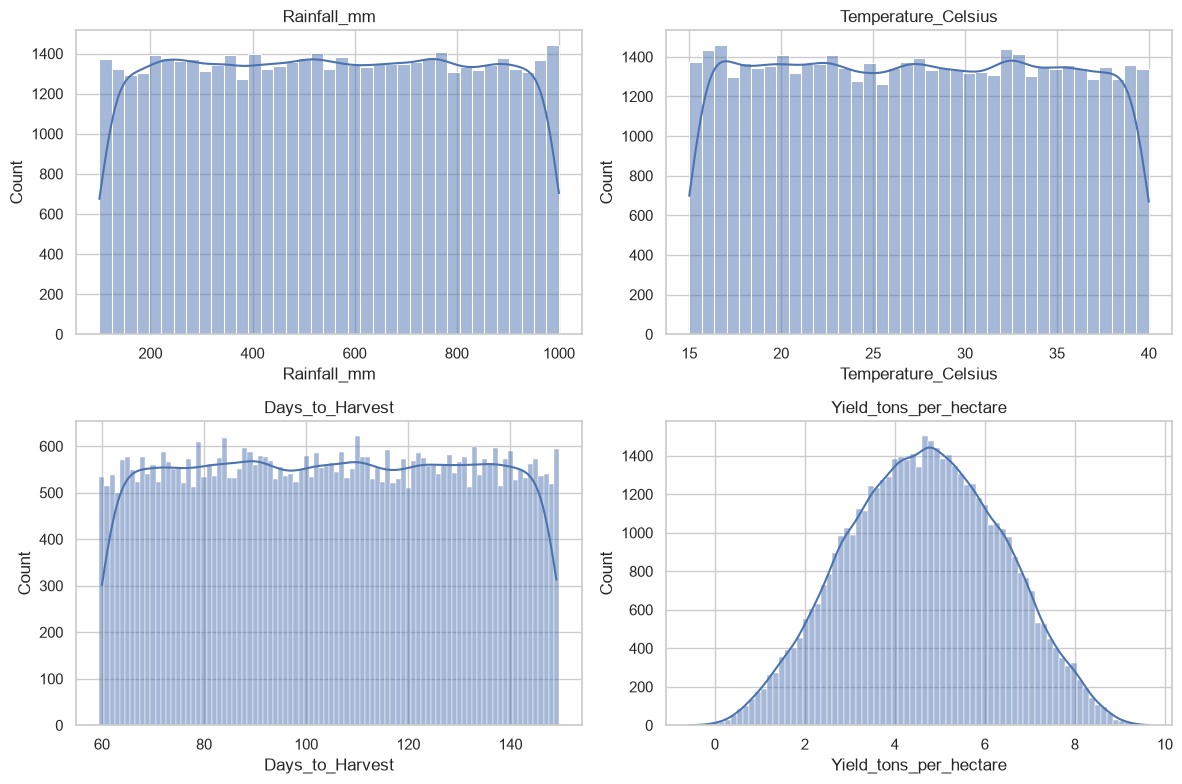

In [5]:
cy_sample = cy.sample(50000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]):
    sns.histplot(cy_sample[col], kde=True, ax=ax, discrete=(col == "Days_to_Harvest"))
    ax.set_title(col)
plt.tight_layout()
plt.show()

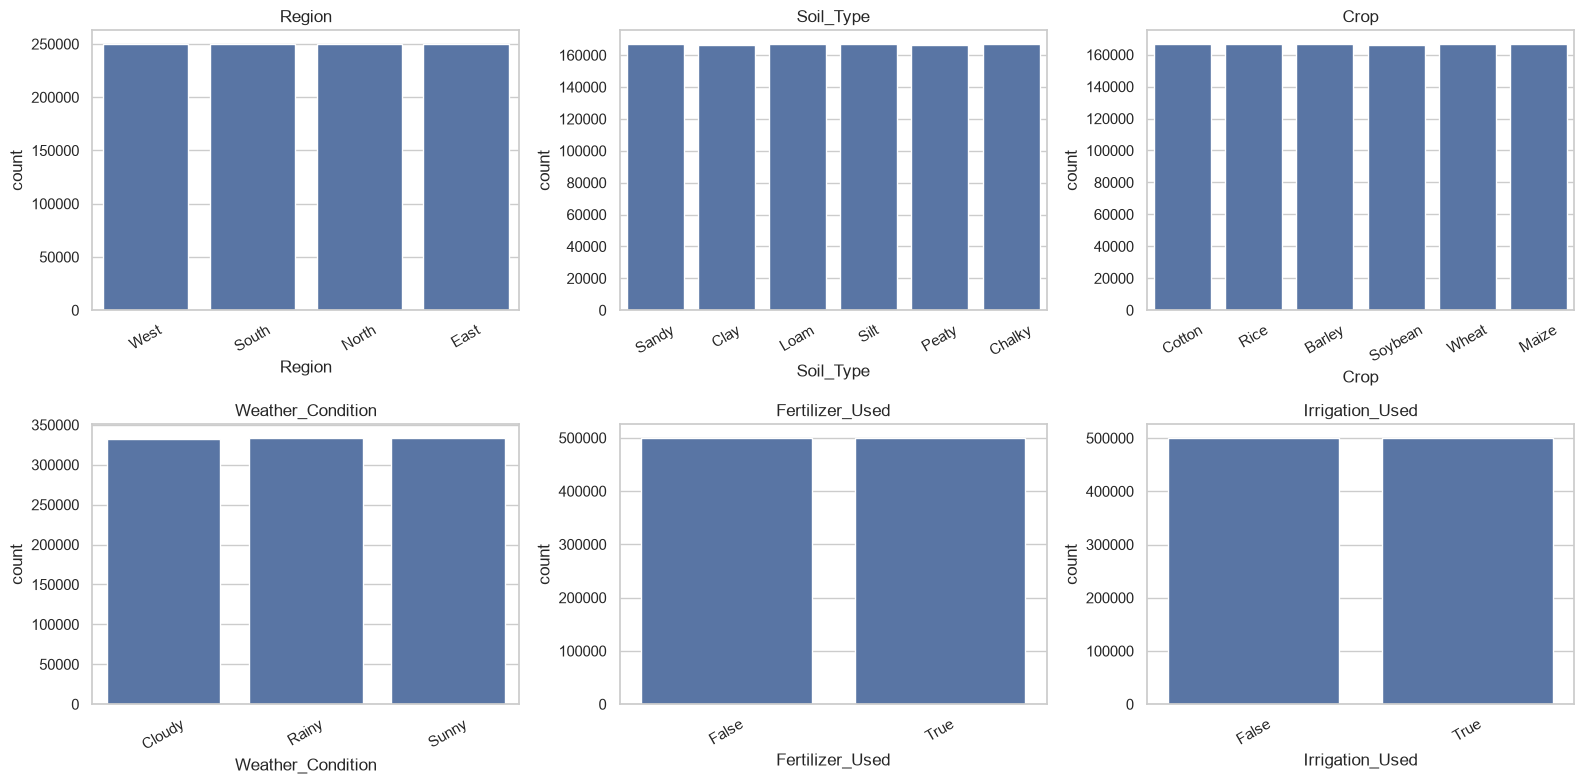

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, ["Region", "Soil_Type", "Crop", "Weather_Condition", "Fertilizer_Used", "Irrigation_Used"]):
    sns.countplot(x=cy[col], ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Nettoyage : rendements négatifs (aberrants)

Un rendement (`Yield_tons_per_hectare`) ne peut pas être négatif physiquement. On identifie et supprime ces lignes aberrantes (probablement issues du bruit ajouté à la génération du dataset).

In [7]:
n_negative = (cy["Yield_tons_per_hectare"] < 0).sum()
print(f"Rendements négatifs : {n_negative} lignes ({n_negative / len(cy):.3%} du dataset)")

cy_clean = cy[cy["Yield_tons_per_hectare"] >= 0].copy()
print("Shape après nettoyage :", cy_clean.shape)

Rendements négatifs : 231 lignes (0.023% du dataset)
Shape après nettoyage : (999769, 10)


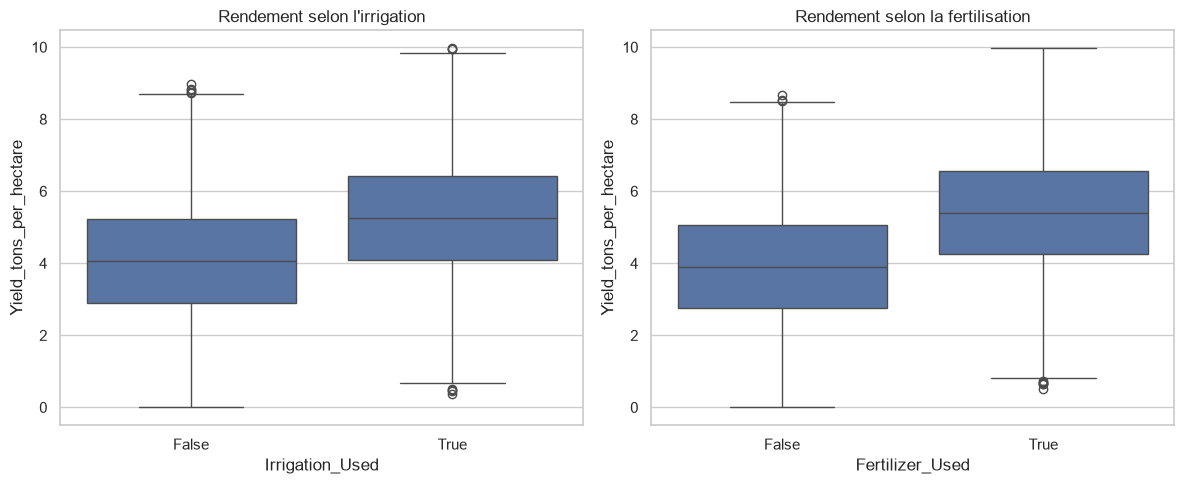

In [8]:
# Corrélations numériques + effet des facteurs agronomiques sur le rendement
num_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=cy_clean, x="Irrigation_Used", y="Yield_tons_per_hectare", ax=axes[0])
axes[0].set_title("Rendement selon l'irrigation")
sns.boxplot(data=cy_clean, x="Fertilizer_Used", y="Yield_tons_per_hectare", ax=axes[1])
axes[1].set_title("Rendement selon la fertilisation")
plt.tight_layout()
plt.show()

## 2. Exploration de l'Agriculture CropYield Dataset (`yield_df.csv`)

Ce fichier est déjà la fusion (par les auteurs originaux) de 4 sources FAO : `yield.csv` (rendement par pays/culture/année), `rainfall.csv`, `pesticides.csv` et `temp.csv`. Il contient un rendement réel par pays, culture et année. **C'est notre dataset secondaire** : sans pays/année dans `crop_yield.csv`, il ne peut être rattaché qu'au niveau culture. Agrégé par culture, il fournira un **proxy pesticides** et une **référence de rendement réel** pour validation.

In [9]:
yd = pd.read_csv(RAW + "yield_df.csv").drop(columns=["Unnamed: 0"])
print("Shape:", yd.shape)
display(yd.dtypes)
yd.head()

Shape: (28242, 7)


Area                                 str
Item                                 str
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [10]:
print("Valeurs manquantes par colonne :")
display(yd.isna().sum())
print("\nCultures (Item) :", sorted(yd["Item"].unique()))
print("Nombre de pays (Area) :", yd["Area"].nunique())
print("Plage d'années :", yd["Year"].min(), "-", yd["Year"].max())

Valeurs manquantes par colonne :


Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


Cultures (Item) : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']
Nombre de pays (Area) : 101
Plage d'années : 1990 - 2013


### Nettoyage : doublons

Deux niveaux de doublons sont présents :
1. **Doublons exacts** (toutes colonnes identiques) → à supprimer directement.
2. **Doublons partiels** sur la clé `(Area, Item, Year)` avec une valeur d'`avg_temp` différente d'une ligne à l'autre, alors que `hg/ha_yield`, `average_rain_fall_mm_per_year` et `pesticides_tonnes` sont eux constants pour une même clé. Cela vient probablement d'un artefact de la fusion d'origine avec `temp.csv` (plusieurs relevés de température par pays/année). On les regroupe en moyennant `avg_temp` : le rendement et les autres variables, déjà constants, ne sont pas affectés.

In [11]:
print("Doublons exacts :", yd.duplicated().sum())
print("Doublons sur (Area, Item, Year) avant nettoyage :", yd.duplicated(subset=["Area", "Item", "Year"]).sum())

key = ["Area", "Item", "Year"]
n_yield_per_key = yd.groupby(key)["hg/ha_yield"].nunique()
print("Clés (Area, Item, Year) avec plusieurs valeurs de rendement différentes :", (n_yield_per_key > 1).sum(), "/", len(n_yield_per_key))

Doublons exacts : 2310
Doublons sur (Area, Item, Year) avant nettoyage : 15112
Clés (Area, Item, Year) avec plusieurs valeurs de rendement différentes : 0 / 13130


In [12]:
yd_dedup = yd.drop_duplicates()
print("Après suppression des doublons exacts :", yd_dedup.shape)

yd_clean = (
    yd_dedup.groupby(key, as_index=False)
    .agg(
        {
            "hg/ha_yield": "first",
            "average_rain_fall_mm_per_year": "first",
            "pesticides_tonnes": "first",
            "avg_temp": "mean",
        }
    )
)
print("Après regroupement des clés (Area, Item, Year) :", yd_clean.shape)
yd_clean.head()

Après suppression des doublons exacts : (25932, 7)
Après regroupement des clés (Area, Item, Year) : (13130, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Maize,1991,29068,1485.0,121.0,15.36
2,Albania,Maize,1992,24876,1485.0,121.0,16.06
3,Albania,Maize,1993,24185,1485.0,121.0,16.05
4,Albania,Maize,1994,25848,1485.0,201.0,16.96


### Harmonisation des unités

`crop_yield.csv` exprime le rendement en **tonnes/hectare**, alors que `yield_df.csv` l'exprime en **hg/ha** (hectogrammes/hectare, unité FAO). On convertit `hg/ha_yield` en tonnes/ha (1 t = 10 000 hg) pour que les deux datasets soient comparables et que le dataset final ait une unité unique et lisible.

In [13]:
yd_clean["Yield_tons_per_hectare"] = yd_clean["hg/ha_yield"] / 10_000
yd_clean = yd_clean.drop(columns=["hg/ha_yield"])
yd_clean = yd_clean.rename(
    columns={
        "average_rain_fall_mm_per_year": "Rainfall_mm",
        "avg_temp": "Temperature_Celsius",
        "pesticides_tonnes": "Pesticides_tonnes",
        "Area": "Country",
        "Item": "Crop",
    }
)
yd_clean.describe()

,Year,Rainfall_mm,Pesticides_tonnes,Temperature_Celsius,Yield_tons_per_hectare
count,13130.000000,13130.000000,13130.000000,13130.000000,13130.000000
mean,2001.622772,1157.238766,14838.697886,19.862651,7.096862
std,7.033139,743.622488,33652.454670,6.661978,7.912428
min,1990.000000,51.000000,0.040000,1.300000,0.005000
25%,1995.000000,608.000000,264.530000,15.754000,1.800000
50%,2001.000000,1083.000000,2172.200000,20.620000,3.954350
75%,2008.000000,1651.000000,13335.220000,25.793684,9.715225
max,2013.000000,3240.000000,367778.000000,30.420000,50.141200


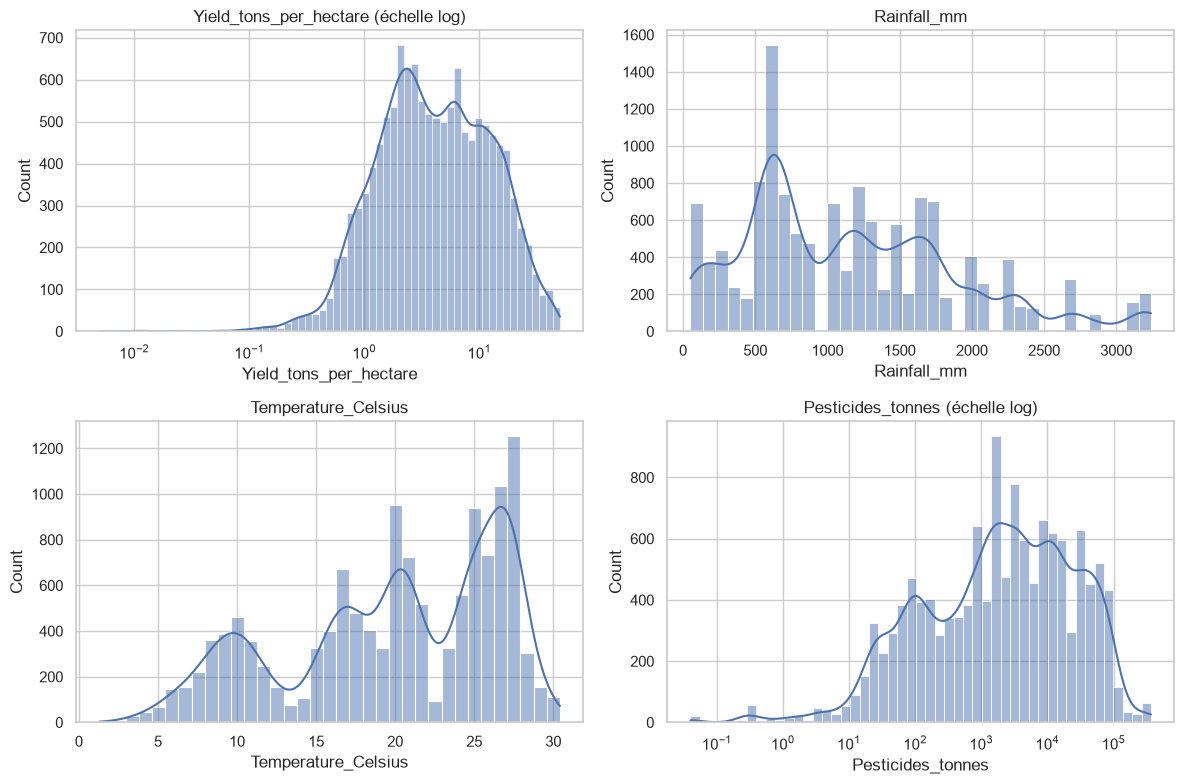

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
log_scale_cols = {"Yield_tons_per_hectare", "Pesticides_tonnes"}  # distributions très asymétriques (longue traîne)
for ax, col in zip(axes.flat, ["Yield_tons_per_hectare", "Rainfall_mm", "Temperature_Celsius", "Pesticides_tonnes"]):
    sns.histplot(yd_clean[col], kde=True, ax=ax, log_scale=col in log_scale_cols)
    ax.set_title(col + (" (échelle log)" if col in log_scale_cols else ""))
plt.tight_layout()
plt.show()

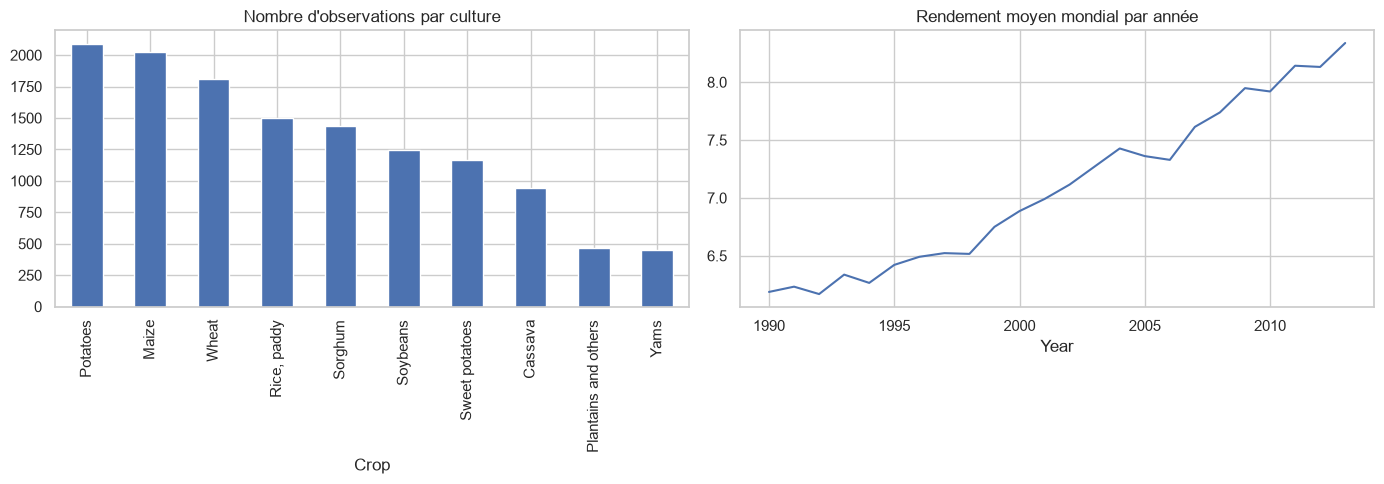

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yd_clean["Crop"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Nombre d'observations par culture")
yd_clean.groupby("Year")["Yield_tons_per_hectare"].mean().plot(ax=axes[1])
axes[1].set_title("Rendement moyen mondial par année")
plt.tight_layout()
plt.show()

## 3. Stratégie de fusion

**Clé de jointure disponible.** `crop_yield.csv` n'a ni pays ni année (seulement une région générique East/North/South/West sans rapport avec les pays de `yield_df.csv`). La seule clé commune est la culture (`Crop` / `Item`). La fusion ne peut donc pas se faire ligne à ligne.

**Sens de la fusion.** `crop_yield.csv` est le dataset principal : il garde sa granularité complète (une ligne par parcelle, avec ses vraies valeurs de sol, météo, irrigation, fertilisation, jours jusqu'à récolte). C'est **`yield_df.csv` qu'on agrège par culture** pour produire un indicateur de référence (proxy pesticides, rendement réel moyen), puis on rattache cet agrégat à chaque ligne de `crop_yield.csv` partageant la même culture (`left join` sur `Crop`, base = `crop_yield.csv`).

**Correspondance des cultures.** Les intitulés diffèrent entre les deux sources (ex. `"Rice, paddy"` vs `"Rice"`). On établit une table de correspondance manuelle.

**Variable proxy retenue.** Seul `Pesticides_tonnes_avg_proxy` (agrégé par culture depuis `yield_df.csv`) est importable : c'est la seule information absente de `crop_yield.csv`. Pluviométrie et température existent déjà, réelles et à la granularité parcelle, dans `crop_yield.csv` — pas besoin de les réimporter (et l'aggrégation par culture de `yield_df.csv` serait de toute façon moins précise). `Irrigation_Used`, `Fertilizer_Used`, `Days_to_Harvest`, `Soil_Type` et `Weather_Condition` restent tels quels, ce sont déjà des colonnes natives de `crop_yield.csv`, pas des variables importées.

In [16]:
crop_crosswalk = {
    "Maize": "Maize",
    "Rice, paddy": "Rice",
    "Soybeans": "Soybean",
    "Wheat": "Wheat",
}
matched_crops = set(crop_crosswalk.values())

print("Cultures crop_yield.csv (principal) :", sorted(cy_clean["Crop"].unique()))
print("Cultures yield_df.csv (secondaire)  :", sorted(yd_clean["Crop"].unique()))
print("Cultures avec correspondance :", sorted(matched_crops))
print("Cultures sans correspondance (proxy = NaN) :", sorted(set(cy_clean["Crop"].unique()) - matched_crops))

Cultures crop_yield.csv (principal) : ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']
Cultures yield_df.csv (secondaire)  : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']
Cultures avec correspondance : ['Maize', 'Rice', 'Soybean', 'Wheat']
Cultures sans correspondance (proxy = NaN) : ['Barley', 'Cotton']


In [17]:
# Agrégation du proxy pesticides + référence de validation, par culture (depuis yield_df.csv)
yd_clean["Crop"] = yd_clean["Crop"].replace(crop_crosswalk)

yield_agg = yd_clean.groupby("Crop").agg(
    Pesticides_tonnes_avg_proxy=("Pesticides_tonnes", "mean"),
    Yield_reference_tons_per_hectare=("Yield_tons_per_hectare", "mean"),  # pour validation uniquement
).reset_index()
yield_agg

,Crop,Pesticides_tonnes_avg_proxy,Yield_reference_tons_per_hectare
0,Cassava,13535.276334,10.270532
1,Maize,13735.498111,3.698035
2,Plantains and others,5555.971810,11.083792
3,Potatoes,13257.036442,18.260182
4,Rice,16443.811451,3.754165
5,Sorghum,14773.143519,1.799532
6,Soybean,20043.068696,1.656375
7,Sweet potatoes,15464.912614,10.431653
8,Wheat,15075.697000,3.078299
9,Yams,17350.488789,10.375882


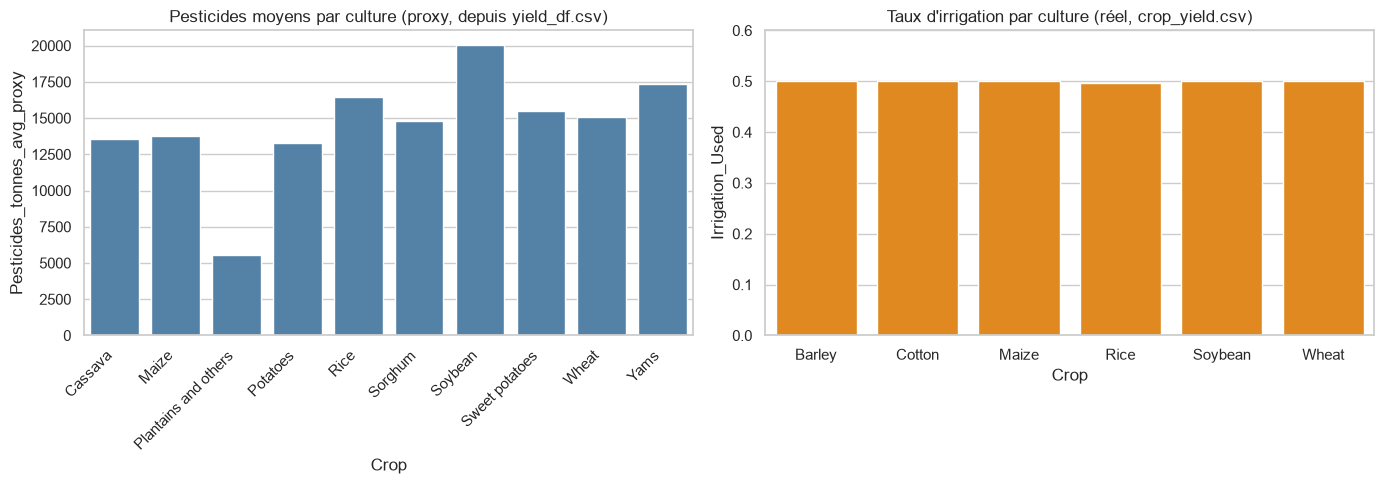

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=yield_agg, x="Crop", y="Pesticides_tonnes_avg_proxy", ax=axes[0], color="steelblue")
axes[0].set_title("Pesticides moyens par culture (proxy, depuis yield_df.csv)")
axes[0].tick_params(axis="x", rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

irrigation_by_crop = cy_clean.groupby("Crop")["Irrigation_Used"].mean().reset_index()
sns.barplot(data=irrigation_by_crop, x="Crop", y="Irrigation_Used", ax=axes[1], color="darkorange")
axes[1].set_title("Taux d'irrigation par culture (réel, crop_yield.csv)")
axes[1].set_ylim(0, 0.6)
plt.tight_layout()
plt.show()

### Fusion : `crop_yield.csv` (base) enrichi par le proxy pesticides de `yield_df.csv`

`crop_yield.csv` est le dataset principal : on garde **toutes ses lignes et ses 6 cultures** (Barley, Cotton, Maize, Rice, Soybean, Wheat), y compris Barley et Cotton qui n'existent pas dans `yield_df.csv`. La fusion se fait en `left join` sur `Crop` : `Pesticides_tonnes_avg_proxy` sera `NaN` pour Barley et Cotton, faute de correspondance dans `yield_df.csv`.

In [19]:
df_unified = cy_clean.merge(
    yield_agg.drop(columns=["Yield_reference_tons_per_hectare"]), on="Crop", how="left"
)

print(f"Lignes : {len(df_unified)} (toutes les cultures de crop_yield.csv conservées)")
print(f"Cultures : {sorted(df_unified['Crop'].unique())}")
print(f"Cultures avec proxy pesticides disponible : {sorted(matched_crops)}")
print("\nValeurs manquantes après fusion :")
display(df_unified.isna().sum())

Lignes : 999769 (toutes les cultures de crop_yield.csv conservées)
Cultures : ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']
Cultures avec proxy pesticides disponible : ['Maize', 'Rice', 'Soybean', 'Wheat']

Valeurs manquantes après fusion :


Region                              0
Soil_Type                           0
Crop                                0
Rainfall_mm                         0
Temperature_Celsius                 0
Fertilizer_Used                     0
Irrigation_Used                     0
Weather_Condition                   0
Days_to_Harvest                     0
Yield_tons_per_hectare              0
Pesticides_tonnes_avg_proxy    333275
dtype: int64

## 4. Dataset unifié final

Colonnes retenues : identifiants (`Region`, `Soil_Type`, `Crop`), cible (`Yield_tons_per_hectare`), variables agronomiques réelles de la parcelle (`Rainfall_mm`, `Temperature_Celsius`, `Fertilizer_Used`, `Irrigation_Used`, `Weather_Condition`, `Days_to_Harvest`), et le proxy pesticides par culture (`Pesticides_tonnes_avg_proxy`). Pas de `Country`/`Year` : absents du dataset principal `crop_yield.csv`. Toutes les cultures de `crop_yield.csv` sont conservées ; le proxy est `NaN` pour Barley et Cotton, absentes de `yield_df.csv`.

In [20]:
col_order = [
    "Region", "Soil_Type", "Crop", "Yield_tons_per_hectare",
    "Rainfall_mm", "Temperature_Celsius",
    "Fertilizer_Used", "Irrigation_Used", "Weather_Condition", "Days_to_Harvest",
    "Pesticides_tonnes_avg_proxy",
]
df_unified = df_unified[col_order].sort_values(["Crop", "Region"]).reset_index(drop=True)
print("Shape finale :", df_unified.shape)
print("Doublons :", df_unified.duplicated().sum())
print("\nValeurs manquantes par colonne :")
display(df_unified.isna().sum())
df_unified.describe(include="all")

Shape finale : (999769, 11)
Doublons : 0

Valeurs manquantes par colonne :


Region                              0
Soil_Type                           0
Crop                                0
Yield_tons_per_hectare              0
Rainfall_mm                         0
Temperature_Celsius                 0
Fertilizer_Used                     0
Irrigation_Used                     0
Weather_Condition                   0
Days_to_Harvest                     0
Pesticides_tonnes_avg_proxy    333275
dtype: int64

,Region,Soil_Type,Crop,Yield_tons_per_hectare,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Pesticides_tonnes_avg_proxy
count,999769,999769,999769,999769.000000,999769.000000,999769.000000,999769,999769,999769,999769.000000,666494.000000
unique,4,6,6,NaN,NaN,NaN,2,2,3,NaN,NaN
top,North,Sandy,Maize,NaN,NaN,NaN,True,False,Sunny,NaN,NaN
freq,250112,167081,166785,NaN,NaN,NaN,499940,500278,333701,NaN,NaN
mean,NaN,NaN,NaN,4.650592,550.077823,27.506079,NaN,NaN,NaN,104.495141,16322.162698
std,NaN,NaN,NaN,1.695166,259.804329,7.220488,NaN,NaN,NaN,25.953328,2349.760624
min,NaN,NaN,NaN,0.000411,100.000896,15.000034,NaN,NaN,NaN,60.000000,13735.498111
25%,NaN,NaN,NaN,3.418669,325.062906,21.256078,NaN,NaN,NaN,82.000000,13735.498111
50%,NaN,NaN,NaN,4.652333,550.229205,27.509509,NaN,NaN,NaN,104.000000,15075.697000
75%,NaN,NaN,NaN,5.879576,774.797949,33.754459,NaN,NaN,NaN,127.000000,16443.811451


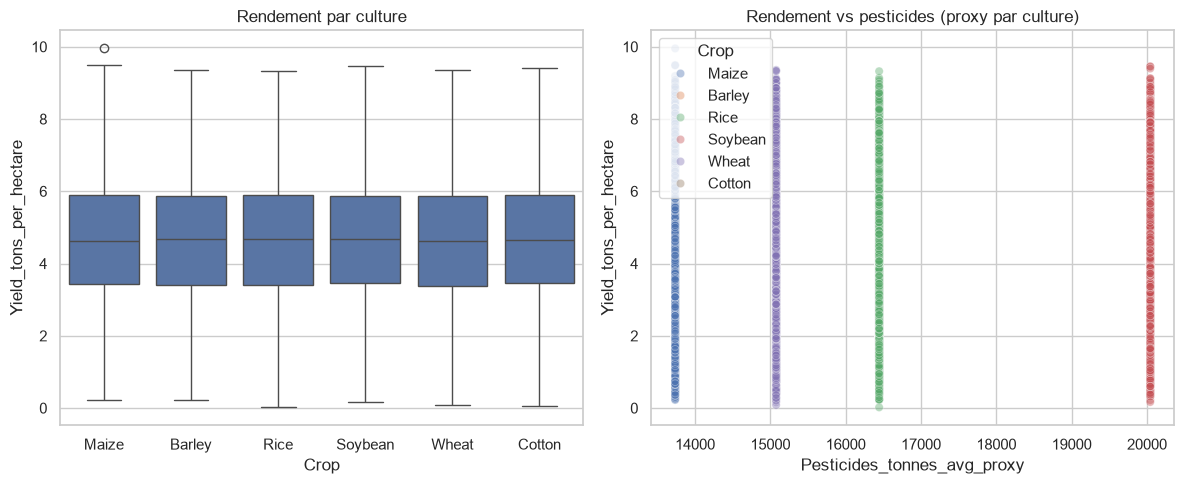

In [21]:
df_unified_sample = df_unified.sample(50_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_unified_sample, x="Crop", y="Yield_tons_per_hectare", ax=axes[0])
axes[0].set_title("Rendement par culture")
sns.scatterplot(data=df_unified_sample, x="Pesticides_tonnes_avg_proxy", y="Yield_tons_per_hectare", hue="Crop", alpha=0.4, ax=axes[1])
axes[1].set_title("Rendement vs pesticides (proxy par culture)")
plt.tight_layout()
plt.show()

In [22]:
import os

os.makedirs("processed_data", exist_ok=True)
output_path = "processed_data/dataset_unifie.csv"
df_unified.to_csv(output_path, index=False)
print(f"Dataset unifié exporté : {output_path} ({df_unified.shape[0]} lignes, {df_unified.shape[1]} colonnes)")

Dataset unifié exporté : processed_data/dataset_unifie.csv (999769 lignes, 11 colonnes)


## 5. Résumé des choix (pour le rapport métier)

**Nettoyage**
- `crop_yield.csv` : suppression des rendements négatifs (physiquement impossibles), ~0,02 % des lignes — impact négligeable.
- `yield_df.csv` : suppression des doublons exacts, puis regroupement des lignes dupliquées sur `(Area, Item, Year)` en moyennant `avg_temp` (seule variable qui différait au sein d'une même clé — artefact de la fusion d'origine avec les données de température) ; rendement, pluviométrie et pesticides étaient déjà strictement identiques au sein de chaque groupe, donc aucune perte d'information.
- Harmonisation des unités de rendement en tonnes/hectare (les deux sources utilisaient des unités différentes : hg/ha vs t/ha).

**Stratégie de fusion**
- `crop_yield.csv` est le **dataset principal** (1M lignes, granularité parcelle). Il n'a **aucune clé pays/année**, seulement une région générique. La seule dimension partagée avec `yield_df.csv` est la **culture**.
- `yield_df.csv` est agrégé par culture pour produire un **proxy pesticides** (`Pesticides_tonnes_avg_proxy`, info absente de `crop_yield.csv`) et une **référence de rendement réel** (validation uniquement), puis rattaché à `crop_yield.csv` via une table de correspondance des noms de cultures et une fusion `left`.
- **Toutes les cultures de `crop_yield.csv` (6) sont conservées.** Barley et Cotton n'ont pas d'équivalent dans `yield_df.csv` : leur proxy pesticides est `NaN`, à imputer ou exclure selon le besoin du modèle, sans perdre leurs lignes.
- Le dataset final n'a pas de `Country`/`Year` : ces colonnes n'existent pas dans le dataset principal `crop_yield.csv`.

**Variables clés identifiées pour la prédiction du rendement**
- `Rainfall_mm`, `Temperature_Celsius` (climat de la parcelle)
- `Fertilizer_Used`, `Irrigation_Used` (pratiques agronomiques, réelles — plus des proxys ici, disponibles pour toutes les lignes)
- `Pesticides_tonnes_avg_proxy` (proxy par culture, disponible pour 4 cultures sur 6)
- `Days_to_Harvest`, `Soil_Type`, `Weather_Condition` (contexte agronomique réel de la parcelle)
- `Crop` et `Region` comme variables catégorielles structurantes

**Dataset final** : `processed_data/dataset_unifie.csv`, prêt pour le pipeline d'entraînement.

## 6. Tests statistiques

Objectif : vérifier formellement, sur le dataset unifié, les relations entre les variables explicatives et la cible `Yield_tons_per_hectare` — on regroupe ici toute l'analyse de corrélation et les tests de significativité, plutôt que de la disperser dans les sections précédentes.

- **Variables numériques** : heatmap de corrélation (Pearson) ci-dessous, puis test de significativité (p-value, H0 : corrélation nulle) qu'elle ne donne pas.
- **Variables catégorielles** (`Region`, `Soil_Type`, `Crop`, `Weather_Condition`, `Fertilizer_Used`, `Irrigation_Used`) : ANOVA à un facteur (H0 : rendement moyen identique entre les modalités).

Seuil : α = 0.05. Avec ~1M lignes, la puissance statistique est énorme : un effet minuscule peut ressortir « significatif ». On regarde donc aussi l'ampleur (r sur la heatmap, ou F) et pas seulement la p-value.

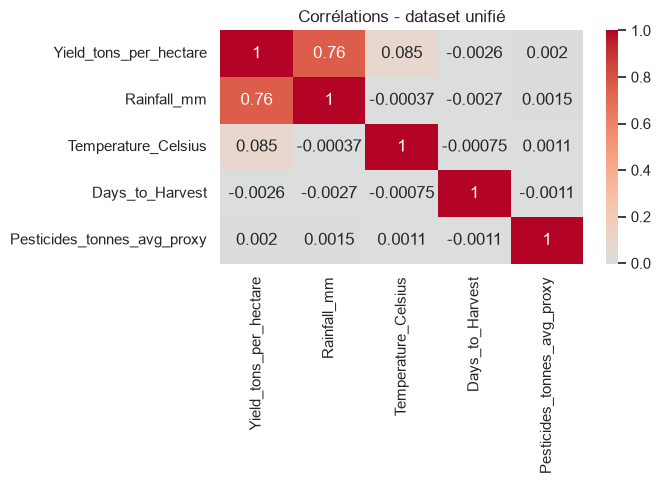

In [23]:
numeric_final = df_unified.select_dtypes(include="number")
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_final.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Corrélations - dataset unifié")
plt.tight_layout()
plt.show()

In [24]:
num_vars = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Pesticides_tonnes_avg_proxy"]

pearson_results = []
for col in num_vars:
    sub = df_unified[[col, "Yield_tons_per_hectare"]].dropna()
    r, p = stats.pearsonr(sub[col], sub["Yield_tons_per_hectare"])
    pearson_results.append({"variable": col, "n": len(sub), "p_value": p, "significatif (5%)": p < 0.05})

pearson_df = pd.DataFrame(pearson_results).sort_values("p_value")
pearson_df

,variable,n,p_value,significatif (5%)
0,Rainfall_mm,999769,0.000000,True
1,Temperature_Celsius,999769,0.000000,True
2,Days_to_Harvest,999769,0.009196,True
3,Pesticides_tonnes_avg_proxy,666494,0.096550,False


In [25]:
cat_vars = ["Region", "Soil_Type", "Crop", "Weather_Condition", "Fertilizer_Used", "Irrigation_Used"]

anova_results = []
for col in cat_vars:
    groups = [g["Yield_tons_per_hectare"].values for _, g in df_unified.groupby(col, observed=True)]
    f_stat, p = stats.f_oneway(*groups)
    anova_results.append({"variable": col, "modalites": len(groups), "F": f_stat, "p_value": p, "significatif (5%)": p < 0.05})

anova_df = pd.DataFrame(anova_results).sort_values("F", ascending=False)
anova_df

,variable,modalites,F,p_value,significatif (5%)
4,Fertilizer_Used,2,242615.553746,0.000000,True
5,Irrigation_Used,2,142734.094973,0.000000,True
2,Crop,6,1.140172,0.336424,False
0,Region,4,1.097507,0.348685,False
3,Weather_Condition,3,0.718623,0.487423,False
1,Soil_Type,6,0.457491,0.808108,False
